<table width="100%" style="border:none; border-collapse:collapse;">
<tr style="border:none;">
<td width="150" style="border:none;"></td>
<td align="center" style="border:none;">
    <h1>Tarea Semanal 4</h1>
    <h2>Teoría de los Circuitos II - R4052</h2>
    <h3>Fabián Alexander Iturrizaga Meza</h3>
    <br>
    <b>Docentes</b><br>
    Profesor: Mariano Llamedo Soria<br>
    Jefe de TPs: César Fuoco<br>
    Ayudante de TPs: David Moharos
</td>
<td width="150" align="right" style="border:none; vertical-align:top;"><img src="./img/logo_UTN.svg" width="150" /></td>
</tr>
</table>

***

## Consigna

<img src="./img/consigna.png" width="800" />

***

## Índice

> **Nota:** los hipervínculos funcionan correctamente en JupyterLab y VS Code abiertos localmente. Si el notebook se visualiza desde **GitHub**, los links pueden no redirigir.

1. [Punto 1 — Función transferencia de Bessel (N=2, 3 y 4) — Método de Storch](#p1)
2. [Punto 2 — Selección del orden mínimo que cumple αmin](#p2)
3. [Punto 3 — Retardo de grupo en ω=2,5 y error porcentual respecto a D(0)](#p3)
4. [Punto 4 — Síntesis del circuito normalizado con Sallen-Key (K=1)](#p4)

**Bonus:**
- [Bonus 1 — Simulación numérica en Python](#b1)
- [Bonus 2 — Desnormalización para D(ω=0) = 200 μs](#b2)
- [Bonus 3 — Simulación en LTSpice con valores desnormalizados](#b3)

---

> **Nota sobre notación:** a lo largo del notebook se utilizan indistintamente $\tau_g(\omega)$ y $D(\omega)$ para referirse al **retardo de grupo**. Ambos simbolizan la misma magnitud:
> $$\tau_g(\omega) = D(\omega) = -\frac{d\,\phi(j\omega)}{d\omega}$$

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
import os
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt

import pytc2
print(f'Versión: {pytc2.__version__}')

from pytc2.sistemas_lineales import (analyze_sys, tf2sos_analog,
                                     pretty_print_lti, pretty_print_SOS,
                                     pzmap)
from pytc2.general import print_subtitle

plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams['figure.dpi'] = 150
plt.rcParams.update({'font.size': 11})

Versión: 0.2.1


<a id="p1"></a>

***

## Punto 1 — Función transferencia de Bessel para N=2, 3 y 4 (Método de Storch)

### Resolución manuscrita

Originales: `p1_hoja_1.jpg` a `p1_hoja_3.jpg` en [img/](./img/)

<img src="./img/p1_hoja_1.jpg" width="450" />
<img src="./img/p1_hoja_2.jpg" width="450" />
<img src="./img/p1_hoja_3.jpg" width="450" />

---

### Transcripción

#### 1.1 Base del método

Para la aproximación de **Bessel-Thomson**, la función transferencia normalizada es:

$$T(s) = \frac{1}{\text{senh}(s) + \cosh(s)}$$

La clave del **método de Storch** es expandir $\coth(s) = \cosh(s)/\text{senh}(s)$ como fracción continua y truncarla al orden $n$ deseado:

$$\coth(s) = \frac{\cosh(s)}{\text{senh}(s)} = \frac{1}{s} + \cfrac{1}{\dfrac{3}{s} + \cfrac{1}{\dfrac{5}{s} + \cfrac{1}{\dfrac{7}{s} + \cdots}}}$$

El orden $n$ de la fracción continua determina el orden del filtro. La función transferencia resultante es:

$$T_n(s) = \frac{1}{\text{senh}(s) + \cosh(s)}\bigg|_{\text{truncado en }n}$$

> **Tip de verificación:** $\cosh(s)$ debe ser una función **par** en $s$ y $\text{senh}(s)$ una función **impar**.

---

#### 1.2 Orden n=1

Truncando en el primer término: $\coth(s) \approx \dfrac{1}{s}$, lo que implica $\cosh(s) = 1$, $\text{senh}(s) = s$.

$$\boxed{T_1(s) = \frac{1}{s + 1}}$$

> Igual que la aproximación de máxima planicidad (Butterworth) y Chebyshev de orden $n=1$.

---

#### 1.3 Orden n=2

$$\coth(s) \approx \frac{1}{s} + \frac{s}{3} = \frac{s^2+3}{3s} \implies \cosh(s) = s^2+3,\quad \text{senh}(s) = 3s$$

$$T(s) = \frac{1}{3s + s^2+3} \xrightarrow{\;T(0)=1\;} \boxed{T_2(s) = \frac{3}{s^2 + 3s + 3}}$$

---

#### 1.4 Orden n=3

$$\coth(s) \approx \frac{s^2+15}{s^3+15s} \cdot \frac{s^3+15s}{s^2+15} \implies \cosh(s) = 6s^2+15,\quad \text{senh}(s) = s^3+15s$$

$$T(s) = \frac{1}{s^3 + 6s^2 + 15s + 15} \xrightarrow{\;T(0)=1\;} \boxed{T_3(s) = \frac{15}{s^3 + 6s^2 + 15s + 15}}$$

---

#### 1.5 Orden n=4

$$\coth(s) \approx \frac{10s^2+105}{s^4+45s^2+105} \implies \cosh(s) = s^4+45s^2+105,\quad \text{senh}(s) = 10s^3+105s$$

$$T(s) = \frac{1}{s^4 + 10s^3 + 45s^2 + 105s + 105} \xrightarrow{\;T(0)=1\;} \boxed{T_4(s) = \frac{105}{s^4 + 10s^3 + 45s^2 + 105s + 105}}$$

In [50]:
# ── Especificaciones ─────────────────────────────────────────────────────────
alpha_max_dB = 1.0    # dB — máxima atenuación en banda de paso
omega_p      = 1.0    # rad/s — borde de banda de paso
omega_s      = 2.5    # rad/s — borde de banda de rechazo

# ── Filtros de Bessel normalizados a D(ω=0) = 1s  (norm='delay') ─────────────
# La norma 'delay' garantiza que el retardo de grupo en DC sea exactamente 1s,
# que es lo que pide la consigna.
bessel_sos = {}
bessel_tf  = {}

for n in [2, 3, 4]:
    z, p, k = sig.besselap(n, norm='delay')
    num, den = sig.zpk2tf(z, p, k)
    sos = tf2sos_analog(num, den)
    bessel_sos[n] = sos
    bessel_tf[n]  = sig.TransferFunction(num, den)

    print_subtitle(f'Bessel pasa-bajo de orden {n}  —  D(0) = 1 s')
    print('T(s) =')
    pretty_print_lti(num.tolist(), den.tolist())
    print('Secciones (ω₀ y Q):')
    pretty_print_SOS(sos, mode='omegayq')
    print()


#### Bessel pasa-bajo de orden 2  —  D(0) = 1 s

T(s) =


<IPython.core.display.Math object>

Secciones (ω₀ y Q):


<IPython.core.display.Math object>

...

#### Bessel pasa-bajo de orden 4  —  D(0) = 1 s

T(s) =


<IPython.core.display.Math object>

Secciones (ω₀ y Q):


<IPython.core.display.Math object>

<a id="p2"></a>

***

## Punto 2 — Selección del orden mínimo que cumple αmax

### Resolución manuscrita

Original: `p2_hoja_1.jpg` en [img/](./img/)

<img src="./img/p2_hoja_1.jpg" width="450" />

---

### Transcripción

Se verifica qué órdenes cumplen la especificación $\alpha(\omega_p=1) \leq \alpha_{\max} = 1\,\text{dB}$, evaluando el módulo en $\omega = 1\,\text{rad/s}$ para cada $T_n(s)$.

#### n=2

$$T_2(j\omega)\big|_{\omega=1} = \frac{3}{(3-1)+j\,3} = \frac{3}{2+3j} \implies |T_2(j1)| = \frac{3}{\sqrt{4+9}} = \frac{3}{\sqrt{13}} \approx 0{,}832$$

$$\alpha(1) = -20\log_{10}(0{,}832) \approx 1{,}60\,\text{dB} > 1\,\text{dB} \quad \textbf{✗ No cumple}$$

#### n=3

$$T_3(j\omega)\big|_{\omega=1} = \frac{15}{(15-6)+j(15-1)} = \frac{15}{9+14j} \implies |T_3(j1)| = \frac{15}{\sqrt{81+196}} = \frac{15}{\sqrt{277}} \approx 0{,}902$$

$$\alpha(1) = -20\log_{10}(0{,}902) \approx 0{,}90\,\text{dB} < 1\,\text{dB} \quad \textbf{✓ Cumple}$$

$$\boxed{N_{\min} = 3}$$

#### Verificación α(ωp=1) ≤ αmax = 1 dB

    N |    α(ωp=1) [dB] | ≤ αmax?
  -----------------------------------
    2 |          1.5970 | ✗
    3 |          0.9030 | ✓  ← orden mínimo
    4 |          0.6300 | ✓

  → Orden mínimo seleccionado: N = 3


#### Bode comparativo N=2, 3, 4

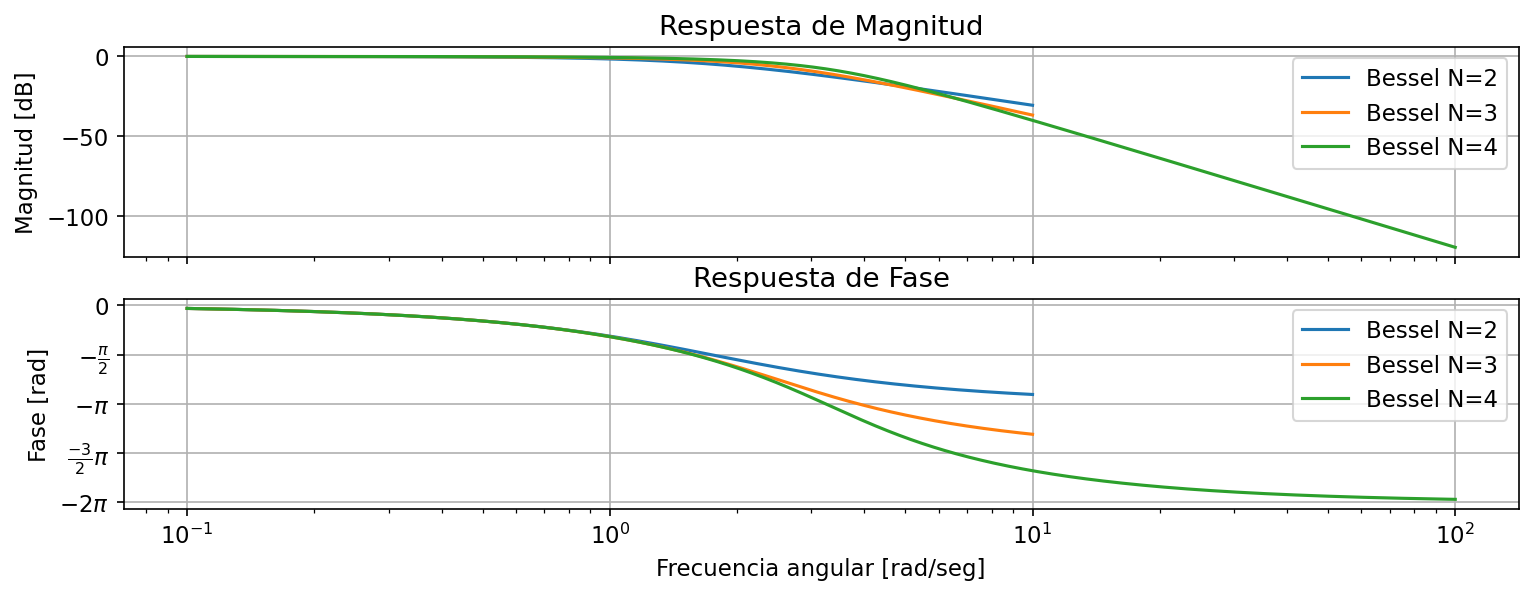

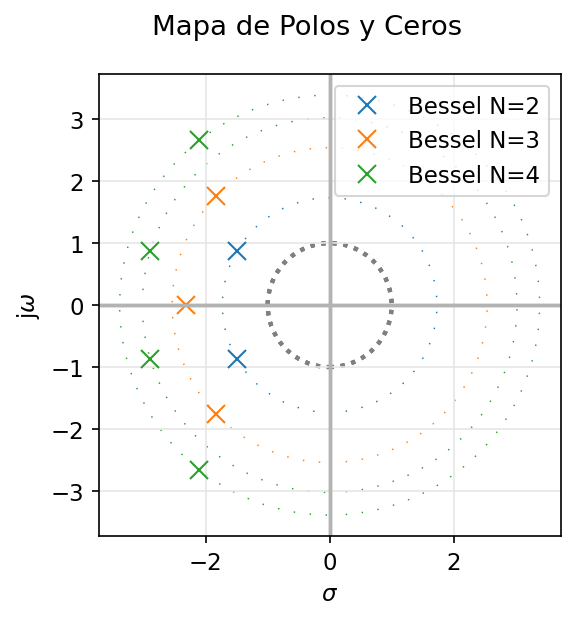

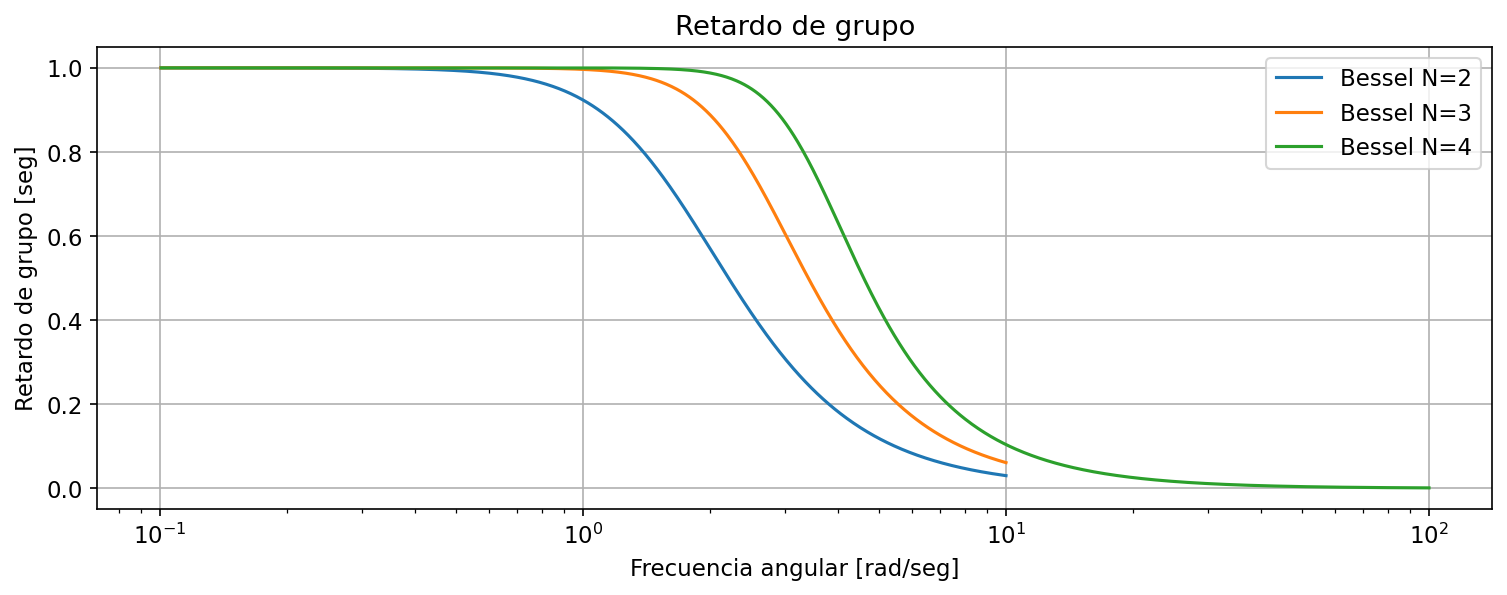

#### Filtro seleccionado — Bessel N=3

<IPython.core.display.Math object>

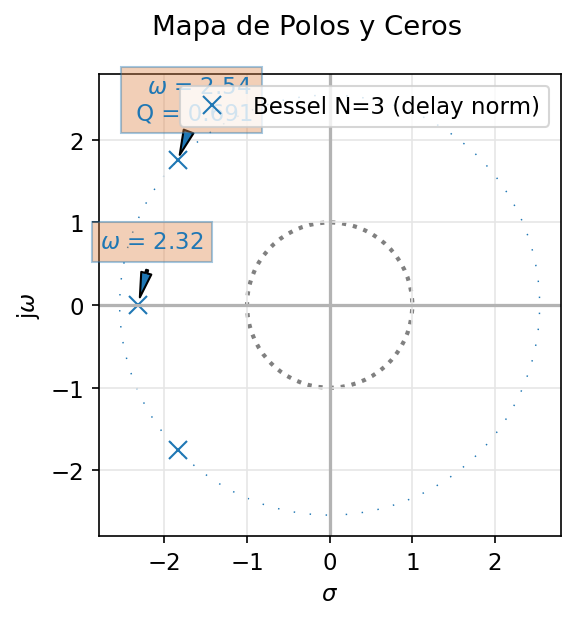

#### Zoom en ωp = 1 rad/s — cumplimiento de αmax = 1 dB

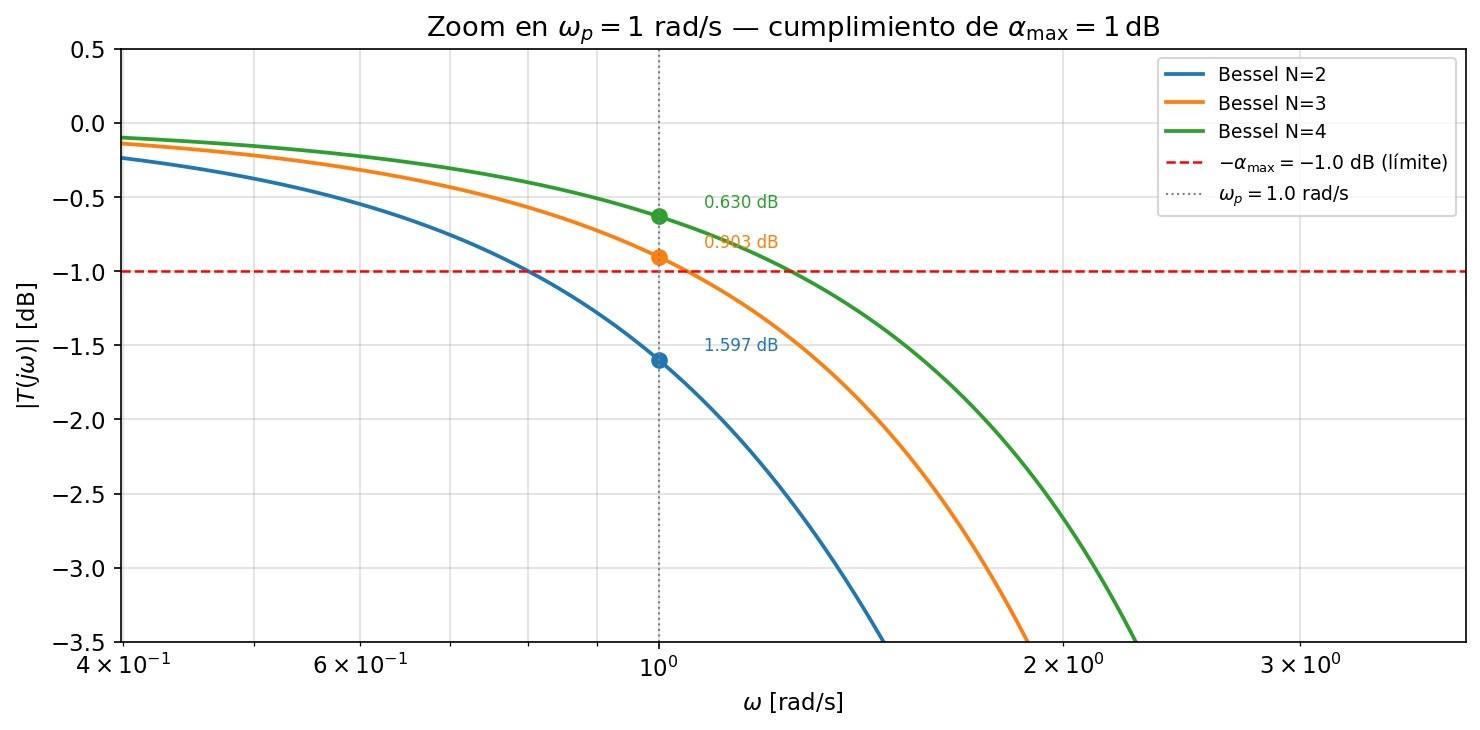

In [51]:
# ── Verificación de la especificación αmax = 1 dB en ωp = 1 rad/s ────────────
print_subtitle('Verificación α(ωp=1) ≤ αmax = 1 dB')
print(f'  {"N":>3} | {"α(ωp=1) [dB]":>15} | {"≤ αmax?"}' )
print(f'  {"-"*35}')

n_min = None
for n in [2, 3, 4]:
    _, H_wp = sig.freqs(bessel_tf[n].num, bessel_tf[n].den, worN=[omega_p])
    alpha_db = -20 * np.log10(abs(H_wp[0]))
    ok = alpha_db <= alpha_max_dB + 1e-6
    marca = '✓' if ok else '✗'
    if ok and n_min is None:
        n_min = n
        marca += '  ← orden mínimo'
    print(f'  {n:>3} | {alpha_db:>15.4f} | {marca}')

print(f'\n  → Orden mínimo seleccionado: N = {n_min}')

# ── Bode comparativo de los tres órdenes con pytc2 ────────────────────────────
print_subtitle('Bode comparativo N=2, 3, 4')

tf_list   = [bessel_tf[n]  for n in [2, 3, 4]]
names     = [f'Bessel N={n}' for n in [2, 3, 4]]

analyze_sys(tf_list, sys_name=names, xaxis='omega',
            annotations=False, same_figs=False)
plt.show()

# ── Detalle del orden elegido: pzmap + SOS ───────────────────────────────────
print_subtitle(f'Filtro seleccionado — Bessel N={n_min}')
pretty_print_SOS(bessel_sos[n_min], mode='omegayq')
pzmap(bessel_tf[n_min], annotations=True,
      filter_description=f'Bessel N={n_min} (delay norm)')
plt.show()

# ── Zoom en ω ≈ 1 para ver el cumplimiento de αmax ───────────────────────────
print_subtitle('Zoom en ωp = 1 rad/s — cumplimiento de αmax = 1 dB')

w_zoom = np.logspace(-0.4, 0.6, 2000)   # ≈ 0.4 a 4 rad/s
colors = ['C0', 'C1', 'C2']

fig, ax = plt.subplots(figsize=[10, 5])

for n, color in zip([2, 3, 4], colors):
    _, H = sig.freqs(bessel_tf[n].num, bessel_tf[n].den, worN=w_zoom)
    ax.semilogx(w_zoom, 20*np.log10(np.abs(H)), color=color, lw=1.8,
                label=f'Bessel N={n}')
    # Marca puntual en ω=1
    _, H_wp = sig.freqs(bessel_tf[n].num, bessel_tf[n].den, worN=[omega_p])
    alpha_wp = -20*np.log10(abs(H_wp[0]))
    ax.plot(omega_p, -alpha_wp, 'o', color=color, ms=7)
    ax.annotate(f'{alpha_wp:.3f} dB',
                xy=(omega_p, -alpha_wp),
                xytext=(omega_p * 1.08, -alpha_wp + 0.06),
                fontsize=8, color=color)

# αmax = 1 dB límite
ax.axhline(-alpha_max_dB, color='red', ls='--', lw=1.2,
           label=f'$-\\alpha_{{\\max}} = -{alpha_max_dB}$ dB (límite)')
ax.axvline(omega_p, color='gray', ls=':', lw=1.0, label=f'$\\omega_p = {omega_p}$ rad/s')

ax.set_xlabel('$\\omega$ [rad/s]')
ax.set_ylabel('$|T(j\\omega)|$ [dB]')
ax.set_title('Zoom en $\\omega_p = 1$ rad/s — cumplimiento de $\\alpha_{\\max} = 1\,\\text{dB}$')
ax.set_ylim(-3.5, 0.5)
ax.set_xlim(w_zoom[0], w_zoom[-1])
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()


<a id="p3"></a>

***

## Punto 3 — Retardo de grupo en ω=2,5 r/s y error porcentual respecto a D(ω=0)

### Resolución manuscrita

Original: `p3_hoja_1.jpg` en [img/](./img/)

<img src="./img/p3_hoja_1.jpg" width="450" />

---

### Transcripción

#### 3.1 Factorización de T₃(s)

$$T_3(s) = \frac{15}{s^3+6s^2+15s+15} = \frac{2{,}3221}{s+2{,}3221} \cdot \frac{6{,}4616}{s^2+3{,}6787\,s+6{,}4616} = T_1(s)\cdot T_2(s)$$

| Sección | Parámetro | Valor |
|:---|:---|:---:|
| 1er orden LP | $\sigma_1$ | $2{,}3221$ |
| 2do orden LP | $\omega_0 = \sqrt{6{,}4616}$ | $2{,}5420$ |
| 2do orden LP | $\omega_0/Q = 3{,}6787$ | $Q = 0{,}6909$ |

#### 3.2 Derivación del retardo de grupo (retomado de TS3)

$$\boxed{\tau_g(\omega) = -\frac{d\,\phi(j\omega)}{d\omega}}, \qquad \tau_g(\omega) = \tau_1(\omega) + \tau_2(\omega)$$

##### Sección de 1er orden LP: $T_1(s) = \dfrac{\sigma_1}{s+\sigma_1}$

El numerador $\sigma_1$ es una constante real positiva → aporta fase nula. La fase total es:

$$\phi_1(j\omega) = -\arctan\!\left(\frac{\omega}{\sigma_1}\right)$$

Derivando respecto a $\omega$:

$$\tau_1(\omega) = \frac{d}{d\omega}\!\left[\arctan\!\left(\frac{\omega}{\sigma_1}\right)\right] = \frac{1/\sigma_1}{1+(\omega/\sigma_1)^2} \qquad \Rightarrow \qquad \boxed{\tau_1(\omega) = \frac{\sigma_1}{\sigma_1^2 + \omega^2}}$$

##### Sección de 2do orden LP: $T_2(s) = \dfrac{\omega_0^2}{s^2 + \frac{\omega_0}{Q}s + \omega_0^2}$

El numerador $\omega_0^2$ es real positivo → aporta fase nula. La fase es:

$$\phi_2(j\omega) = -\phi_{D_2}(j\omega), \quad D_2(j\omega) = \underbrace{(\omega_0^2-\omega^2)}_{\text{Re}} + j\underbrace{\frac{\omega_0\,\omega}{Q}}_{\text{Im}}$$

$$\phi_{D_2}(j\omega) = \arctan\!\left(\frac{\omega_0\,\omega/Q}{\omega_0^2-\omega^2}\right) \qquad \Rightarrow \qquad \phi_2(j\omega) = -\arctan\!\left(\frac{\omega_0\,\omega/Q}{\omega_0^2-\omega^2}\right)$$

Sea $u = \dfrac{\omega_0\,\omega/Q}{\omega_0^2-\omega^2}$; aplicando la regla de la cadena:

$$\frac{du}{d\omega} = \frac{\omega_0}{Q}\cdot\frac{\omega_0^2+\omega^2}{(\omega_0^2-\omega^2)^2}, \qquad 1+u^2 = \frac{(\omega_0^2-\omega^2)^2+(\omega_0\omega/Q)^2}{(\omega_0^2-\omega^2)^2}$$

$$\tau_2(\omega) = \frac{d\phi_{D_2}}{d\omega} = \frac{du/d\omega}{1+u^2} \qquad \Rightarrow \qquad \boxed{\tau_2(\omega) = \frac{(\omega_0/Q)\,(\omega_0^2+\omega^2)}{(\omega_0^2-\omega^2)^2 + (\omega_0\,\omega/Q)^2}}$$

> **Observación:** la fórmula de $\tau_2$ es **idéntica** a la obtenida para la sección HP en TS3. La diferencia está en la fase inicial: la sección LP parte de $\phi(0)=0$ mientras que la HP parte de $\phi(0)=\pi$. Pero al derivar, esa constante desaparece y la expresión del retardo es la misma. Los valores numéricos difieren por la distinta ubicación de los polos.

##### Casos notables

**En $\omega \to 0$:**

$$\tau_1(0) = \frac{1}{\sigma_1}, \qquad \tau_2(0) = \frac{\omega_0/Q \cdot \omega_0^2}{\omega_0^4} = \frac{1}{\omega_0\,Q} \qquad \Rightarrow \qquad \tau_g(0) = \frac{1}{\sigma_1} + \frac{1}{\omega_0\,Q}$$

#### 3.3 Verificación D(ω=0) = 1 s

$$\tau_g(0) = \frac{1}{2{,}3221} + \frac{3{,}6787}{6{,}4616} \approx 0{,}4307 + 0{,}5695 \approx \boxed{1\,\text{s}} \;\checkmark$$

#### 3.4 Evaluación en ω=2,5 r/s

$$\tau_g(2{,}5) = \frac{2{,}3221}{2{,}3221^2+6{,}25} + \frac{3{,}6787\,(6{,}4616+6{,}25)}{(6{,}4616-6{,}25)^2+(2{,}5\cdot3{,}6787)^2} \approx 0{,}1994 + 0{,}5527 \approx \boxed{0{,}752\,\text{s}}$$

#### 3.5 Error porcentual

$$e_{\%} = \frac{|D(\omega_s) - D(0)|}{D(0)} \times 100 = \frac{|0{,}752 - 1|}{1} \times 100 \approx \boxed{24{,}8\,\%}$$

#### Parámetros de T₃(s)  —  Bessel N=3 (delay norm)

  Polo real:      σ₁     = 2.322185
  Par complejo:   ω₀     = 2.541541
                  ω₀/Q   = 3.677815
                  Q      = 0.691047


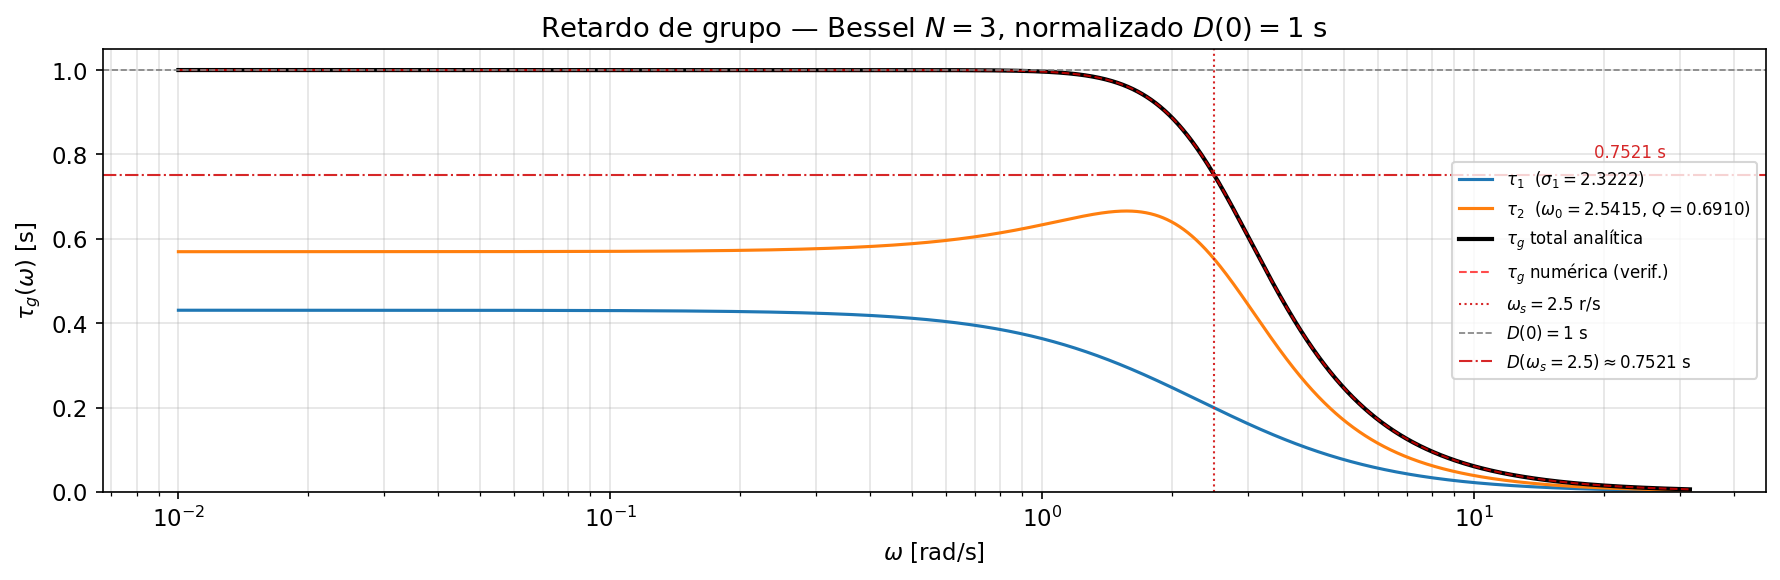

#### Verificación analítica

  D(ω=0)  = 1.000000 s   (esperado: 1.0000 s)  ✓
  D(ω=0) fórmula: 1/σ₁ + 1/(ω₀·Q) = 0.430629 + 0.569371 = 1.000000 s

  D(ωs=2.5) = 0.752083 s   (manuscrito: ≈ 0.7520 s)

  Error % = |D(ωs) - D(0)| / D(0) × 100
          = |0.7521 - 1| / 1 × 100
          = 24.79 %


In [52]:
# ── Parámetros del filtro N=3 seleccionado ───────────────────────────────────
# (viene de p2_code: n_min = 3)
n_sel = 3
z3, p3, k3 = sig.besselap(n_sel, norm='delay')
num3, den3 = sig.zpk2tf(z3, p3, k3)

# Extraer parámetros de los polos
p_real = [p for p in p3 if abs(p.imag) < 1e-9][0] # Extraigo polos reales
p_cx   = [p for p in p3 if p.imag > 0][0]         # Extraigo polos cc
sigma1 = abs(p_real.real)
w0     = abs(p_cx)
w0_Q   = -2 * p_cx.real       # coef de s en el denominador SOS = ω₀/Q
Q      = w0 / w0_Q

print_subtitle(f'Parámetros de T₃(s)  —  Bessel N={n_sel} (delay norm)')
print(f'  Polo real:      σ₁     = {sigma1:.6f}')
print(f'  Par complejo:   ω₀     = {w0:.6f}')
print(f'                  ω₀/Q   = {w0_Q:.6f}')
print(f'                  Q      = {Q:.6f}')

# ── Fórmulas analíticas del retardo de grupo que obtuvimos en el papel -─────
def tau1(w, s1):    return s1 / (s1**2 + w**2)
def tau2(w, w0, w0Q): return w0Q*(w0**2+w**2) / ((w0**2-w**2)**2 + (w*w0Q)**2)
def tau_total(w, s1, w0, w0Q): return tau1(w, s1) + tau2(w, w0, w0Q)

w_gd = np.logspace(-2, 1.5, 4000)
tau_an  = tau_total(w_gd, sigma1, w0, w0_Q)
tau1_an = tau1(w_gd, sigma1)
tau2_an = tau2(w_gd, w0, w0_Q)

# Verificación numérica (diferenciación de la fase)
_, H3 = sig.freqs(num3, den3, worN=w_gd)
tau_num = -np.gradient(np.unwrap(np.angle(H3)), w_gd)

# ── Gráfico ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=[12, 4])
ax.semilogx(w_gd, tau1_an,  'C0-',  lw=1.5, label=f'$\\tau_1$  ($\\sigma_1={sigma1:.4f}$)')
ax.semilogx(w_gd, tau2_an,  'C1-',  lw=1.5, label=f'$\\tau_2$  ($\\omega_0={w0:.4f}$, $Q={Q:.4f}$)')
ax.semilogx(w_gd, tau_an,   'k-',   lw=2.0, label='$\\tau_g$ total analítica')
ax.semilogx(w_gd, tau_num,  'r--',  lw=1.0, label='$\\tau_g$ numérica (verif.)', alpha=0.7)
ax.axvline(omega_s, color='C3', ls=':', lw=1.0, label=f'$\\omega_s={omega_s}$ r/s')
ax.axhline(1.0, color='gray', ls='--', lw=0.8, label='$D(0)=1$ s')
# Línea horizontal en D(ωs)
_tau_ws = tau_total(omega_s, sigma1, w0, w0_Q)
ax.axhline(_tau_ws, color='C3', ls='-.', lw=1.0,
           label=f'$D(\\omega_s={omega_s}) \\approx {_tau_ws:.4f}$ s')
ax.annotate(f'{_tau_ws:.4f} s',
            xy=(w_gd[-1]*0.6, _tau_ws),
            xytext=(w_gd[-1]*0.6, _tau_ws + 0.04),
            fontsize=8, color='C3')
ax.set_xlabel('$\\omega$ [rad/s]'); ax.set_ylabel('$\\tau_g(\\omega)$ [s]')
ax.set_title('Retardo de grupo — Bessel $N=3$, normalizado $D(0)=1$ s')
ax.set_ylim(0, None); ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.35)
plt.tight_layout(); plt.show()

# ── Verificación casos notables ───────────────────────────────────────────────
tau_dc  = tau_total(1e-5, sigma1, w0, w0_Q)
tau_ws  = tau_total(omega_s, sigma1, w0, w0_Q)
error_pct = abs(tau_ws - 1.0) / 1.0 * 100

print_subtitle('Verificación analítica')
print(f'  D(ω=0)  = {tau_dc:.6f} s   (esperado: 1.0000 s)  {"✓" if abs(tau_dc-1)<0.001 else "✗"}')
print(f'  D(ω=0) fórmula: 1/σ₁ + 1/(ω₀·Q) = {1/sigma1:.6f} + {1/(w0*Q):.6f} = {1/sigma1+1/(w0*Q):.6f} s')
print()
print(f'  D(ωs={omega_s}) = {tau_ws:.6f} s   (manuscrito: ≈ 0.7520 s)')
print()
print(f'  Error % = |D(ωs) - D(0)| / D(0) × 100')
print(f'          = |{tau_ws:.4f} - 1| / 1 × 100')
print(f'          = {error_pct:.2f} %')


<a id="p4"></a>

***

## Punto 4 — Síntesis del circuito normalizado con Sallen-Key (K=1)

### Resolución manuscrita

Originales: `p4_hoja_1.jpg` a `p4_hoja_4.jpg` en [img/](./img/)

<img src="./img/p4_hoja_1.jpg" width="600" />
<img src="./img/p4_hoja_2.jpg" width="450" />
<img src="./img/p4_hoja_3.jpg" width="450" />
<img src="./img/p4_hoja_4.jpg" width="450" />

---

### Transcripción

El filtro $T_3(s)$ tiene dos secciones en cascada separadas por buffer:

$$T_3(s) = \underbrace{\frac{6{,}4616}{s^2 + 3{,}6787\,s + 6{,}4616}}_{T_{\text{SOS}}(s)\;\text{Sallen-Key 2do orden}} \cdot \underbrace{\frac{2{,}3221}{s + 2{,}3221}}_{T_{\text{RC}}(s)\;\text{RC 1er orden}}$$

#### 4.1 Sallen-Key LP de 2do orden (K=1, ganancia real y unitaria)

**Topología:** $V_i \to R_1 \to V_x \to R_2 \to V_y \;(+)$; $C_2$ de feedback desde $V_o$ a $V_x$; $C_1$ shunt desde $V_y$ a masa.

Aplicando el Método de Nodos y Admitancias:

$$V_x\!\left(\tfrac{1}{R_1}+\tfrac{1}{R_2}+sC_2\right) - V_i\tfrac{1}{R_1} - V_y\tfrac{1}{R_2} - V_o\,sC_2 = 0 \tag{1}$$

$$V_y\!\left(\tfrac{1}{R_2}+sC_1\right) - V_x\tfrac{1}{R_2} = 0 \tag{2}$$

$$V_y = V_o \tag{3}\quad\text{(seguidor de tensión, }K=1\text{)}$$

De $(3)\!\to\!(2)$: $\quad V_x = V_o(1 + sC_1R_2)$ $\quad(4)$

Sustituyendo $(4)$ y $(3)$ en $(1)$ y despejando:

$$\frac{V_o}{V_i} = \frac{\dfrac{1}{R_1 R_2 C_1 C_2}}{s^2 + s\,\dfrac{R_2 C_1 + R_1 C_1}{R_1 R_2 C_1 C_2} + \dfrac{1}{R_1 R_2 C_1 C_2}}$$

En la forma estándar $\omega_0^2/(s^2+(\omega_0/Q)s+\omega_0^2)$ (con K=1):

$$\boxed{\omega_0 = \frac{1}{\sqrt{R_1 R_2 C_1 C_2}}}, \qquad \boxed{Q = \frac{\sqrt{R_1 R_2 C_1 C_2}}{C_1(R_1+R_2)}}$$

#### 4.2 Cálculo de componentes (R₁ = R₂ = 1 Ω)

Con $R_1 = R_2 = 1\,\Omega$, $\omega_0/Q = 2/C_2$ y $\omega_0^2 = 1/(C_1 C_2)$:

$$\frac{\omega_0}{Q} = \frac{2}{C_2} = 3{,}6787 \implies \boxed{C_2 = \frac{2}{3{,}6787} = 0{,}5437\,\text{F}}$$

$$\omega_0^2 = \frac{1}{C_1 C_2} = 6{,}4616 \implies \boxed{C_1 = \frac{1}{6{,}4616 \times 0{,}5437} = 0{,}2847\,\text{F}}$$

#### 4.3 Sección RC de 1er orden

$$T_{\text{RC}}(s) = \frac{1/RC}{s + 1/RC} = \frac{\sigma_1}{s + \sigma_1}, \quad \sigma_1 = \frac{1}{RC} = 2{,}3221$$

Con $R = 1\,\Omega$: $\quad\boxed{C = \frac{1}{2{,}3221} = 0{,}4306\,\text{F}}$

#### 4.4 Tabla de componentes normalizados

| Sección | Componente | Valor |
|:---|:---:|:---:|
| SK 2do orden | $R_1 = R_2$ | $1\,\Omega$ |
| SK 2do orden | $C_1$ | $0{,}2847\,\text{F}$ |
| SK 2do orden | $C_2$ | $0{,}5437\,\text{F}$ |
| RC 1er orden | $R_3$ | $1\,\Omega$ |
| RC 1er orden | $C_3$ | $0{,}4306\,\text{F}$ |

---

### Verificación en LTSpice

#### Circuito simulado

<div align="center"><img src="./img/p4_lt_09.jpg" width="950" /></div>

> **Figura:** circuito en LTSpice. **Sección SK:** $R_1=R_2=1\,\Omega$, $C_1=0{,}2847\,\text{F}$, $C_2=0{,}5437\,\text{F}$, opamp U1 (seguidor). **Buffer** U2. **Sección RC:** $R_3=1\,\Omega$, $C_3=0{,}4306\,\text{F}$. Directivas: `.ac dec 10000 0.001 100`, `.lib opamp.sub`.

---

#### Retardo de grupo — verificación de D(ω=0) = 1 s

<div align="center"><img src="./img/p4_lt_01.jpg" width="950" /></div>

> **Figura:** retardo de grupo en escala lineal. Cursor en $f = 1{,}009\,\text{mHz}$ ($\approx\omega\to 0$):
> $D \approx 999{,}96\,\text{ms} \approx 1\,\text{s}$ ✓ — confirma la normalización $D(\omega=0) = 1\,\text{s}$.

---

#### Retardo de grupo — en ωp = 1 rad/s

<div align="center"><img src="./img/p4_lt_02.jpg" width="950" /></div>

> **Figura:** cursor en $f = 159{,}15\,\text{mHz}$ $\left(= \omega_p/2\pi = 1/2\pi\right)$:
> $D(\omega_p) = 996{,}29\,\text{ms} \approx 1\,\text{s}$ — el retardo se mantiene prácticamente constante en toda la banda de paso, característica distintiva del filtro de Bessel. ✓

---

#### Retardo de grupo — en ωs = 2,5 rad/s

<div align="center"><img src="./img/p4_lt_03.jpg" width="950" /></div>

> **Figura:** cursor en $f = 397{,}83\,\text{mHz}$ $\left(= \omega_s/2\pi = 2{,}5/2\pi\right)$:
> $D(\omega_s) = 752{,}14\,\text{ms}$ — coincide con el valor analítico $0{,}7520\,\text{s}$ ✓.
> Error porcentual: $e_\% = |0{,}752 - 1|/1 \times 100 \approx 24{,}8\,\%$ ✓.

---

#### Módulo — verificación de αmax = 1 dB en ωp

<div align="center"><img src="./img/p4_lt_04.jpg" width="950" /></div>

> **Figura:** módulo en dB. Cursor en $f = 159{,}18\,\text{mHz}$ ($\omega_p = 1\,\text{rad/s}$):
> $|T(j\omega_p)| = -903{,}66\,\mu\text{dB} \approx -0{,}90\,\text{dB} < \alpha_{\max} = 1\,\text{dB}$ ✓.

---

#### Módulo — pendiente en zona de rechazo

<div align="center"><img src="./img/p4_lt_05.jpg" width="950" /></div>

> **Figura:** dos cursores en zona de rechazo.
> - Cursor 1: $1\,\text{Hz}$, $|T| = -25{,}10\,\text{dB}$
> - Cursor 2: $10\,\text{Hz}$, $|T| = -84{,}43\,\text{dB}$
> - $\Delta = 59{,}32\,\text{dB/dec} \approx 60\,\text{dB/dec}$ ✓ — pendiente asintótica de un LPF de orden 3.

---

#### Retardo de grupo — secciones individuales vs total

<div align="center"><img src="./img/p4_lt_06.jpg" width="950" /></div>

> **Figura:** retardo de grupo de cada sección por separado.
> - Rojo $V(v_{\text{osos}})/V(v_i)$: SOS Sallen-Key 2do orden — presenta un pico de retardo ≈ 670 ms en $\omega \approx 0{,}3\,\text{rad/s}$ (propio del par complejo con $Q < 1$).
> - Verde $V(v_o)/V(v_{\text{oSOS}})$: sección RC 1er orden — retardo monótonamente decreciente ≈ 430 ms en DC.
> La suma de ambas produce el retardo total $\approx 1\,\text{s}$ en la banda de paso.

---

#### Fase — secciones individuales

<div align="center"><img src="./img/p4_lt_07.jpg" width="950" /></div>

> **Figura:** fase de cada sección. La sección RC (verde) aporta hasta $-90°$ y la SOS (rojo) hasta $-180°$, totalizando $-270°$ en alta frecuencia, consistente con un filtro de 3er orden.

---

#### Retardo de grupo — las tres curvas superpuestas

<div align="center"><img src="./img/p4_lt_08.jpg" width="950" /></div>

> **Figura:** retardo de grupo de la SOS (rojo), la RC (verde) y la cascada completa (rosa). Se confirma que $\tau_{\text{total}} = \tau_{\text{SOS}} + \tau_{\text{RC}}$: el retardo total en la banda de paso es aproximadamente $1\,\text{s}$ y decrece gradualmente a partir de $\omega \approx 1\,\text{rad/s}$.

#### Punto 4 — Verificación Python del filtro Bessel N=3

Secciones (ω₀ y Q):


<IPython.core.display.Math object>


D(ω→0) = 1.00000 s  (objetivo: 1.0000 s)  ✓
α(ωp=1) = 0.9030 dB  (límite: ≤ 1.0 dB)  ✓


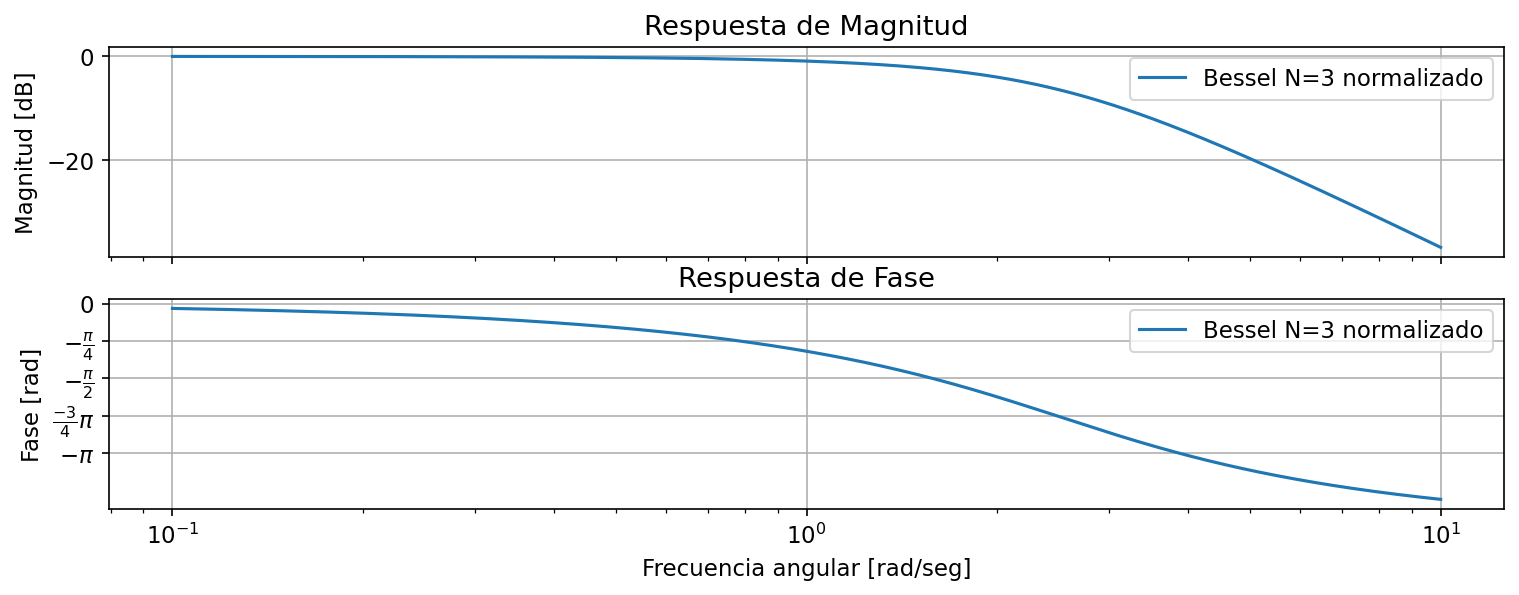

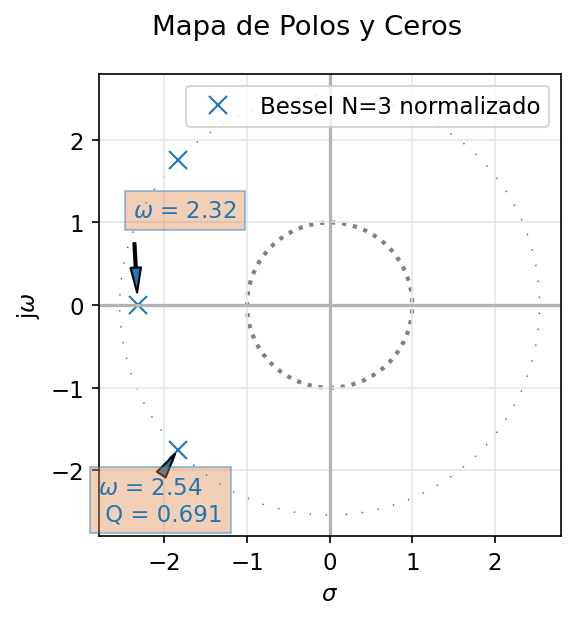

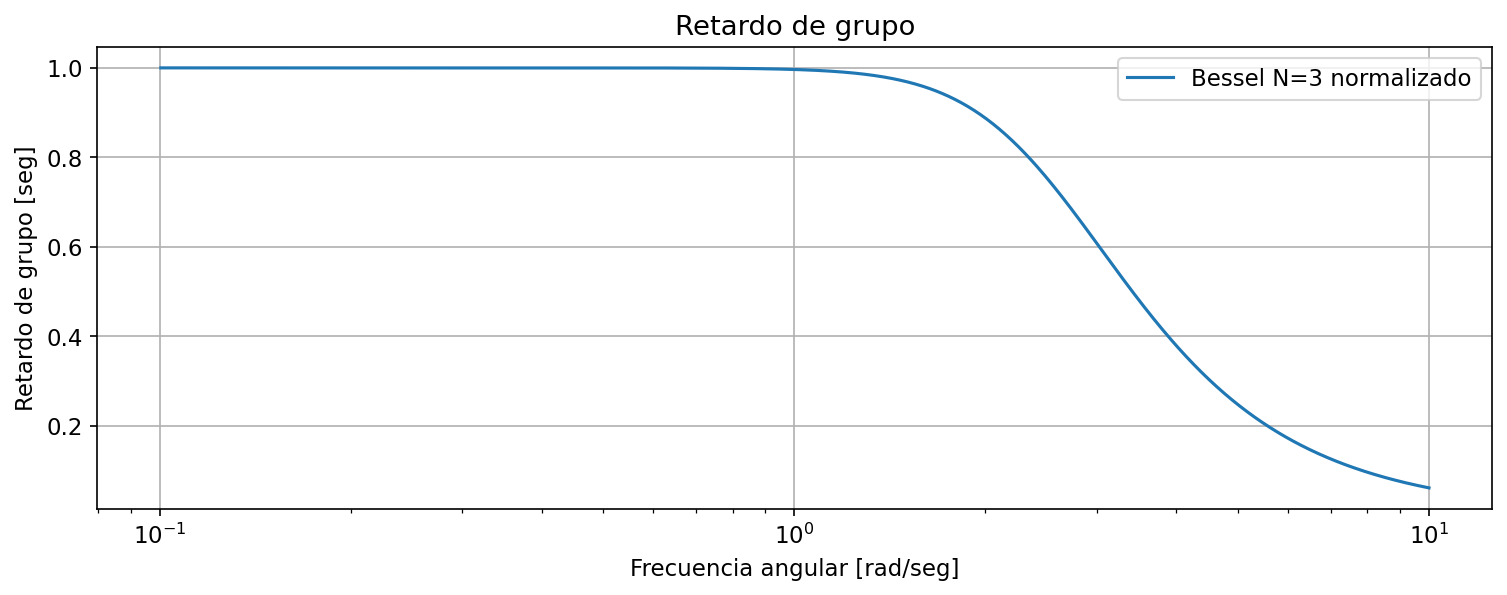

In [56]:
# ── Verificación numérica del circuito Sallen-Key normalizado ─────────────────
# Reconstruye la TF a partir de los componentes diseñados y verifica ω₀, Q, D(0)

# Parámetros del filtro seleccionado (N=3, delay norm)
z3, p3, k3   = sig.besselap(3, norm='delay')
num3, den3   = sig.zpk2tf(z3, p3, k3)
tf3          = sig.TransferFunction(num3, den3)

# SOS del filtro N=3
sos3 = tf2sos_analog(num3, den3)

print_subtitle('Punto 4 — Verificación Python del filtro Bessel N=3')
print('Secciones (ω₀ y Q):')
pretty_print_SOS(sos3, mode='omegayq')

# Verificar D(0) = 1 s
w_v = np.logspace(-4, 2, 5000)
_, H_v = sig.freqs(num3, den3, worN=w_v)
tau_v = -np.gradient(np.unwrap(np.angle(H_v)), w_v)
print(f'\nD(ω→0) = {tau_v[0]:.5f} s  (objetivo: 1.0000 s)  '
      + ('✓' if abs(tau_v[0]-1)<0.01 else '✗'))

# Verificar α(ωp=1) ≤ αmax
_, H_wp = sig.freqs(num3, den3, worN=[omega_p])
alpha_wp = -20*np.log10(abs(H_wp[0]))
print(f'α(ωp=1) = {alpha_wp:.4f} dB  (límite: ≤ {alpha_max_dB} dB)  '
      + ('✓' if alpha_wp <= alpha_max_dB else '✗'))

# Bode + pzmap del filtro
analyze_sys(tf3, sys_name='Bessel N=3 normalizado',
            xaxis='omega', annotations=True, same_figs=False)
plt.show()


<a id="b1"></a>

***

## Bonus 1 — Simulación numérica en Python

La simulación numérica en Python se realizó de forma integrada a lo largo del notebook:

| Punto | Contenido |
|:---|:---|
| **Punto 1** | `sig.besselap(n, norm='delay')` para N=2, 3, 4 — TF polinómica y SOS en ω₀-Q |
| **Punto 2** | Verificación numérica α(ωp=1) ≤ αmax para N=2,3,4 — tabla + Bode comparativo + zoom en ωp |
| **Punto 3** | Retardo de grupo analítico + verificación numérica por diferenciación de fase, gráfico τ_g(ω), cálculo D(0) y D(ωs=2.5) con error % |
| **Punto 4** | Verificación del circuito SK normalizado: SOS en ω₀-Q, D(0)=1s, α(ωp) — Bode + pzmap |

#### Bonus 1 — Resumen: Bessel N=3, D(0)=1s, verificación numérica

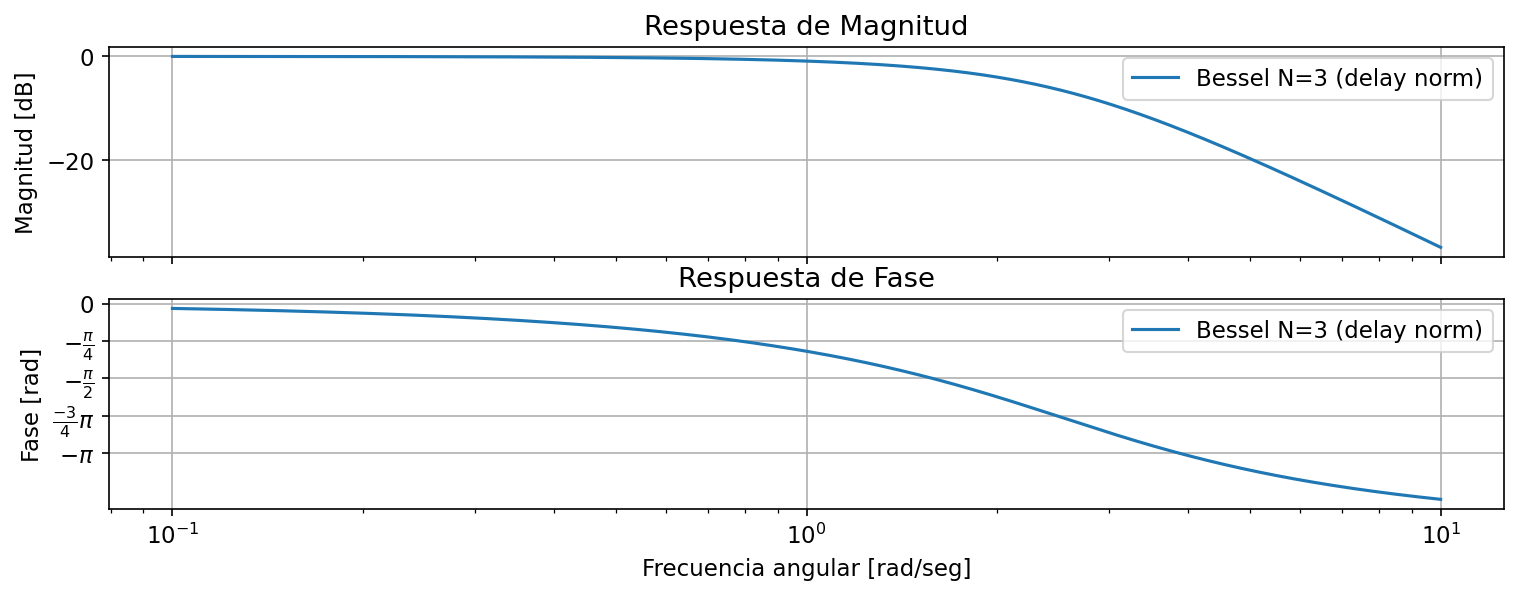

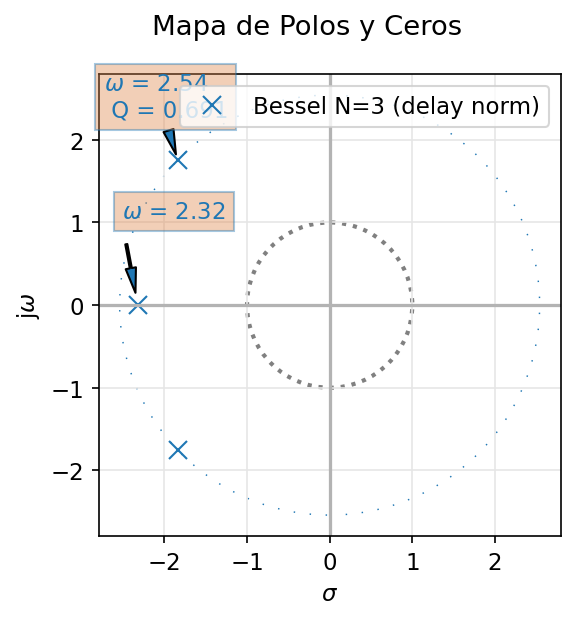

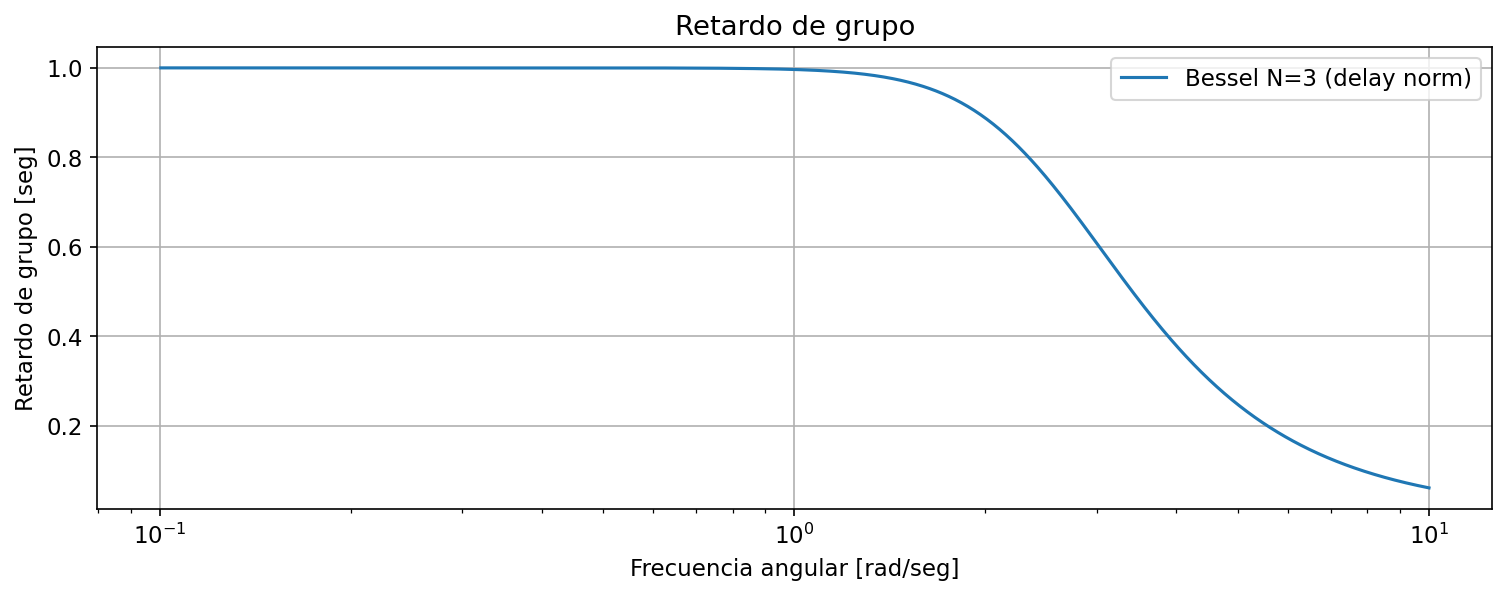

In [54]:
# El Bonus 1 se implementó integrado en los puntos anteriores.
# Esta celda consolida la verificación final del filtro N=3 seleccionado.

print_subtitle('Bonus 1 — Resumen: Bessel N=3, D(0)=1s, verificación numérica')

# Bode + pzmap + retardo del filtro seleccionado
analyze_sys(bessel_tf[3], sys_name='Bessel N=3 (delay norm)',
            xaxis='omega', annotations=True, same_figs=False)
plt.show()


<a id="b2"></a>

***

## Bonus 2 — Desnormalización para D(ω=0) = 200 μs

### Resolución manuscrita

Originales: `b2_hoja_1.jpg` y `b2_hoja_2.jpg` en [img/](./img/)

<img src="./img/b2_hoja_1.jpg" width="450" />
<img src="./img/b2_hoja_2.jpg" width="450" />

---

### Transcripción

#### B2.1 Norma de frecuencia

Se busca $D(\omega=0) = 200\,\mu\text{s}$. La norma de frecuencia es:

$$\Omega_\omega = \frac{1}{D(0)} = \frac{1}{200\,\mu\text{s}} = 5000\,\text{rad/s}$$

*(Referencia: Schaumann, pág. 413, Ej. 10.1)*

#### B2.2 Desnormalización de la TF

La sustitución $s \leftarrow s/\Omega_\omega$ convierte el filtro normalizado al dominio real:

$$T(s)_{\text{desn}} = T(s)_{\text{norm}}\bigg|_{s \;\to\; s/\Omega_\omega}$$

#### B2.3 Desnormalización de componentes

Las **resistencias no se ven afectadas** por $\Omega_\omega$; sólo se reescalan por la norma de impedancia $\Omega_z$.

$$C_{\text{desn}} = \frac{C_{\text{norm}}}{\Omega_\omega \cdot \Omega_z}$$

Se elige $\Omega_z = 10\,\text{k}\Omega$ → $R_1 = R_2 = R_3 = 10\,\text{k}\Omega$.

#### B2.4 Valores desnormalizados

**Sección Sallen-Key (2do orden):**

$$C_1 = \frac{0{,}2847}{5000 \times 10\,000} = \boxed{5{,}694\,\text{nF}}$$

$$C_2 = \frac{0{,}5437}{5000 \times 10\,000} = \boxed{10{,}873\,\text{nF}}$$

**Sección RC (1er orden):**

$$C_3 = \frac{0{,}4306}{5000 \times 10\,000} = \boxed{8{,}612\,\text{nF}}$$

| Sección | Componente | Valor desnormalizado |
|:---|:---:|:---:|
| SK 2do orden | $R_1 = R_2$ | $10\,\text{k}\Omega$ |
| SK 2do orden | $C_1$ | $5{,}694\,\text{nF}$ |
| SK 2do orden | $C_2$ | $10{,}873\,\text{nF}$ |
| RC 1er orden | $R_3$ | $10\,\text{k}\Omega$ |
| RC 1er orden | $C_3$ | $8{,}612\,\text{nF}$ |

#### B2.5 TF desnormalizada

$$T(s) = \frac{1{,}6154\times10^8}{s^2 + 1{,}839\times10^4\,s + 1{,}6154\times10^8} \cdot \frac{1{,}161\times10^4}{s + 1{,}161\times10^4}$$

In [55]:
# ── Parámetros de desnormalización ──────────────────────────────────────────
D0_target = 200e-6        # s  — retardo de grupo objetivo en DC
Omega_w   = 1 / D0_target  # rad/s = 5000
Omega_z   = 10e3           # Ω   — norma de impedancia elegida

print_subtitle('Bonus 2 — Desnormalización')
print(f'  Ωω = 1/D(0) = 1/{D0_target*1e6:.0f}μs = {Omega_w:.0f} rad/s')
print(f'  Ωz = {Omega_z/1e3:.0f} kΩ  (resistencias objetivo)')

# ── Componentes desnormalizados ───────────────────────────────────────────────
R_desn  = Omega_z                          # 10 kΩ
C1_desn = 0.284651 / (Omega_w * Omega_z)   # nF
C2_desn = 0.543670 / (Omega_w * Omega_z)
C3_desn = 0.430644 / (Omega_w * Omega_z)

print(f'\n  SK 2do orden:  R1 = R2 = {R_desn/1e3:.0f} kΩ')
print(f'               C1 = {C1_desn*1e9:.4f} nF  (LTSpice: 5.69302 nF)')
print(f'               C2 = {C2_desn*1e9:.4f} nF  (LTSpice: 10.8734 nF)')
print(f'  RC 1er orden:  R3 = {R_desn/1e3:.0f} kΩ')
print(f'               C3 = {C3_desn*1e9:.4f} nF  (LTSpice: 8.61288 nF)')

# ── TF desnormalizada ─────────────────────────────────────────────────────────
z3, p3, k3   = sig.besselap(3, norm='delay')
num_n, den_n = sig.zpk2tf(z3, p3, k3)
num_d, den_d = sig.lp2lp(num_n, den_n, Omega_w)   # escala de frecuencia

print_subtitle('TF desnormalizada')
pretty_print_lti(num_d.tolist(), den_d.tolist())
print('\nSecciones (ω₀ y Q):')
pretty_print_SOS(tf2sos_analog(num_d, den_d), mode='omegayq')

# ── Verificación D(0) ─────────────────────────────────────────────────────────
_, H_dc = sig.freqs(num_d, den_d, worN=[1e-3])
w_d = np.logspace(0, 5, 5000)
_, H_d = sig.freqs(num_d, den_d, worN=w_d)
tau_d = -np.gradient(np.unwrap(np.angle(H_d)), w_d)
print_subtitle('Verificación D(ω→0)')
print(f'  D(0) = {tau_d[0]*1e6:.2f} μs  (objetivo: {D0_target*1e6:.0f} μs)'
      + ('  ✓' if abs(tau_d[0]-D0_target)/D0_target < 0.01 else '  ✗'))


#### Bonus 2 — Desnormalización

  Ωω = 1/D(0) = 1/200μs = 5000 rad/s
  Ωz = 10 kΩ  (resistencias objetivo)

  SK 2do orden:  R1 = R2 = 10 kΩ
               C1 = 5.6930 nF  (LTSpice: 5.69302 nF)
               C2 = 10.8734 nF  (LTSpice: 10.8734 nF)
  RC 1er orden:  R3 = 10 kΩ
               C3 = 8.6129 nF  (LTSpice: 8.61288 nF)


#### TF desnormalizada

<IPython.core.display.Math object>


Secciones (ω₀ y Q):


<IPython.core.display.Math object>

#### Verificación D(ω→0)

  D(0) = 200.00 μs  (objetivo: 200 μs)  ✓


<a id="b3"></a>

***

## Bonus 3 — Simulación en LTSpice con valores desnormalizados

#### Circuito simulado

<div align="center"><img src="./img/b3_lt_05.jpg" width="950" /></div>

> **Figura:** circuito desnormalizado. **SK:** $R_1=R_2=10\,\text{k}\Omega$, $C_1=5{,}693\,\text{nF}$, $C_2=10{,}873\,\text{nF}$. **Buffer** U2. **RC:** $R_3=10\,\text{k}\Omega$, $C_3=8{,}613\,\text{nF}$. Directivas: `.ac dec 10000 0.1 100000`, `.lib opamp.sub`.

---

#### Retardo de grupo — verificación D(ω=0) = 200 μs

<div align="center"><img src="./img/b3_lt_01.jpg" width="950" /></div>

> **Figura:** retardo de grupo de las tres señales ($V(v_o)/V(v_i)$ en rosa, $V(v_{\text{osos}})/V(v_i)$ en rojo, $V(v_o)/V(v_{\text{oSOS}})$ en verde). Cursor en $f = 1\,\text{mHz}$ ($\omega \to 0$): $D = 200{,}02\,\mu\text{s} \approx 200\,\mu\text{s}$ ✓ — confirma la desnormalización.

---

#### Retardo de grupo — vista completa

<div align="center"><img src="./img/b3_lt_02.jpg" width="950" /></div>

> **Figura:** el retardo de grupo total (rosa) se mantiene plano en $\approx 200\,\mu\text{s}$ hasta aproximadamente $f_p = \omega_p/(2\pi) = 5000/(2\pi) \approx 795\,\text{Hz}$, donde comienza a decrecer. Comportamiento característico del filtro de Bessel.

---

#### Retardo de grupo — cursor en ωp desnormalizado

<div align="center"><img src="./img/b3_lt_03.jpg" width="950" /></div>

> **Figura:** cursor en $f = 795{,}16\,\text{Hz}$ $\left(= \omega_p^{\text{desn}}/(2\pi) = 5000/2\pi\right)$:
> $D(\omega_p) = 199{,}31\,\mu\text{s} \approx 200\,\mu\text{s}$ ✓ — el retardo en el borde de banda de paso es prácticamente igual al retardo en DC, confirmando la planicidad del retardo en toda la banda.

---

#### Módulo — verificación de αmax en ωp

<div align="center"><img src="./img/b3_lt_04.jpg" width="950" /></div>

> **Figura:** módulo en dB de las tres secciones. Cursor en $f = 795{,}16\,\text{Hz}$ ($\omega_p$ desnormalizado):
> $|T(j\omega_p)| = -901{,}53\,\text{mdB} \approx -0{,}90\,\text{dB} < \alpha_{\max} = 1\,\text{dB}$ ✓ — la especificación de módulo se cumple también en el dominio desnormalizado.

---

#### Retardo de grupo - Cursor 1 en banda de paso - Cursor 2 en ωs

<div align="center"><img src="./img/b3_lt_06.jpg" width="950" /></div>

> **Figura:** Retardo de grupo. 
> - Cursor 1 en $f = 100\text{mHz}$ (Banda de paso).
> - Cursor 2 en $f = 1{,}989\,\text{KHz}$ $\left(\omega_s-desnormalizado = 2,5 * 5000/2\pi\right)$: 
> - $D(\omega \approx 0) \approx 200\,\mu\text{s} - D(\omega_s) \approx 150{,}46\,\mu\text{s}$.
> - Error porcentual: $e_\% = |150{,}46 - 200|/200 \times 100 \approx 24{,}8\,\%$ ✓.
> - $\Delta = 49{,}55\,\mu\text{s}$ ✓ — Delta de retardo entre la banda de paso y el inicio de la banda de stop, que dividido por 200 $\mu\text{s}$ y multiplicado por 100 da el $24{,}8\,\%$ calculado.

